# Colab 2. Практический XDM/MFEX-анализ

Блокнот выполняет безмодельный анализ табличного набора данных. Пользователь выбирает медицинский, экономический, социальный пример или свой CSV. На выходе формируются ранги методов, консенсус, MFF-NoFit и правила подгрупп.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.datasets import load_breast_cancer
import statsmodels.api as sm

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
OUT_DIR = Path('xdm_outputs')
OUT_DIR.mkdir(exist_ok=True)
plt.rcParams['figure.figsize'] = (9,5)
plt.rcParams['axes.grid'] = True

# Выбор данных: medical, economic, social, csv
DATA_MODE = 'medical'
CSV_PATH = 'your_file.csv'
TARGET_COLUMN = 'target'

def load_data():
    if DATA_MODE == 'medical':
        data = load_breast_cancer(as_frame=True)
        return data.frame.copy(), 'target', 'Breast Cancer Wisconsin', 'тип опухоли'
    if DATA_MODE == 'economic':
        macro = sm.datasets.macrodata.load_pandas().data.copy()
        macro = macro[['realgdp','realcons','realinv','realgovt','realdpi','cpi','m1','tbilrate','unemp','pop','realint','infl']].dropna()
        macro['high_inflation'] = (macro['infl'] > macro['infl'].median()).astype(int)
        macro = macro.drop(columns=['infl'])
        return macro, 'high_inflation', 'US macrodata high inflation', 'инфляция выше медианы'
    if DATA_MODE == 'social':
        state = sm.datasets.statecrime.load_pandas().data.reset_index().copy()
        state['high_violent_social_risk'] = (state['violent'] > state['violent'].median()).astype(int)
        state = state.drop(columns=['state','violent'])
        return state, 'high_violent_social_risk', 'US state social indicators', 'высокий социальный риск'
    if DATA_MODE == 'csv':
        df = pd.read_csv(CSV_PATH)
        return df, TARGET_COLUMN, CSV_PATH, TARGET_COLUMN
    raise ValueError('Unknown DATA_MODE')

def normalize_score(s):
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    s = s - s.min()
    if s.max() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return s / s.max()

def rank_score(s):
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return s.rank(ascending=False, method='average')

def pairwise_distances(A):
    A = np.asarray(A, dtype=float)
    aa = np.sum(A * A, axis=1)[:, None]
    d2 = np.maximum(aa + aa.T - 2 * A @ A.T, 0.0)
    return np.sqrt(d2)

def distance_structure_score(X_part, y_part):
    A = np.asarray(X_part, dtype=float)
    y_arr = np.asarray(y_part)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    D = pairwise_distances(A)
    i, j = np.triu_indices_from(D, k=1)
    same = y_arr[i] == y_arr[j]
    intra = D[i, j][same].mean()
    inter = D[i, j][~same].mean()
    return (inter - intra) / (abs(inter) + abs(intra) + 1e-12)

def make_bins(x, bins=6):
    try:
        return pd.qcut(x, q=bins, duplicates='drop')
    except Exception:
        return pd.cut(x, bins=bins, duplicates='drop')

def empirical_mutual_information(x, y, bins=6):
    b = make_bins(x, bins=bins)
    table = pd.crosstab(b, y, normalize=True)
    px = table.sum(axis=1).values
    py = table.sum(axis=0).values
    pxy = table.values
    score = 0.0
    for i in range(pxy.shape[0]):
        for j in range(pxy.shape[1]):
            if pxy[i, j] > 0 and px[i] > 0 and py[j] > 0:
                score += pxy[i, j] * np.log(pxy[i, j] / (px[i] * py[j]))
    return float(score)

def relief_like(X, y, neighbors=8):
    A = np.asarray(X, dtype=float)
    y_arr = np.asarray(y)
    n, p = A.shape
    D = pairwise_distances(A)
    np.fill_diagonal(D, np.inf)
    scores = np.zeros(p)
    for i in range(n):
        same_idx = np.where(y_arr == y_arr[i])[0]
        diff_idx = np.where(y_arr != y_arr[i])[0]
        same_idx = same_idx[same_idx != i]
        if len(same_idx) == 0 or len(diff_idx) == 0:
            continue
        hit = same_idx[np.argsort(D[i, same_idx])[:neighbors]]
        miss = diff_idx[np.argsort(D[i, diff_idx])[:neighbors]]
        scores += np.mean(np.abs(A[i] - A[miss]), axis=0) - np.mean(np.abs(A[i] - A[hit]), axis=0)
    return pd.Series(scores / n, index=X.columns)

def run_analysis(df, target_col, dataset_name):
    feature_cols = [c for c in df.columns if c != target_col]
    y = df[target_col].astype(int).reset_index(drop=True)
    raw = df[feature_cols].select_dtypes(include=[np.number]).copy()
    for c in raw.columns:
        raw[c] = raw[c].fillna(raw[c].median())
    X = ((raw - raw.mean()) / raw.std().replace(0,1)).reset_index(drop=True)
    feature_cols = list(X.columns)
    profile = pd.DataFrame({'dataset':[dataset_name], 'objects':[len(df)], 'features':[len(feature_cols)], 'target':[target_col], 'class_1_share':[float((y==1).mean())]})
    profile.to_csv(OUT_DIR/'dataset_profile.csv', index=False)
    class_diff = {}
    for c in feature_cols:
        x0 = X.loc[y==0, c]; x1 = X.loc[y==1, c]
        pooled = np.sqrt((x0.var()+x1.var())/2) + 1e-12
        class_diff[c] = abs(x1.mean()-x0.mean())/pooled
    class_diff = normalize_score(pd.Series(class_diff))
    rank_relation = normalize_score(pd.Series({c: abs(spearmanr(X[c], y)[0]) if not np.isnan(spearmanr(X[c], y)[0]) else 0.0 for c in feature_cols}))
    information = normalize_score(pd.Series({c: empirical_mutual_information(X[c], y) for c in feature_cols}))
    neighbor = normalize_score(relief_like(X, y))
    statistical = normalize_score((information + neighbor)/2)
    base_D = distance_structure_score(X, y)
    geometry = normalize_score(pd.Series({c: max(base_D-distance_structure_score(X[[v for v in feature_cols if v!=c]], y),0.0) for c in feature_cols}))
    Xy = X.copy(); Xy['target'] = y.values
    Z = (Xy - Xy.mean()) / Xy.std().replace(0,1)
    P = np.linalg.pinv(np.cov(Z.values, rowvar=False))
    target_idx = Z.columns.get_loc('target')
    conditional = {}
    for i,c in enumerate(feature_cols):
        conditional[c] = abs(float(-P[i,target_idx]/(np.sqrt(abs(P[i,i]*P[target_idx,target_idx]))+1e-12)))
    conditional = normalize_score(pd.Series(conditional))
    base_rate = y.mean()
    rule_rows=[]; rule_scores=pd.Series(0.0,index=feature_cols)
    for c in feature_cols:
        binned=make_bins(X[c], bins=5)
        for interval in binned.dropna().unique():
            mask=(binned==interval)
            if mask.sum()<max(6,int(0.03*len(X))):
                continue
            rate=float(y[mask].mean()); coverage=float(mask.mean()); q=coverage*abs(rate-base_rate)
            rule_rows.append({'feature':c,'interval':str(interval),'coverage':coverage,'target_rate_in_rule':rate,'base_target_rate':base_rate,'rule_score':q})
    rules=pd.DataFrame(rule_rows).sort_values('rule_score', ascending=False)
    if len(rules):
        for c, part in rules.head(30).groupby('feature'):
            rule_scores[c]=part['rule_score'].sum()
    structural=normalize_score(rule_scores)
    scores=pd.DataFrame({'class_difference':class_diff,'rank_relation':rank_relation,'information':information,'relief_neighbor':neighbor,'statistical_core':statistical,'geometry':geometry,'conditional':conditional,'structural_rules':structural})
    scores.to_csv(OUT_DIR/'xdm_method_scores.csv')
    core=pd.DataFrame({'statistical':statistical,'geometry':geometry,'conditional':conditional,'structural_rules':structural})
    ranks=core.apply(rank_score,axis=0)
    ranks['median_rank']=ranks.median(axis=1)
    ranks['rank_iqr']=ranks[core.columns].quantile(0.75,axis=1)-ranks[core.columns].quantile(0.25,axis=1)
    ranks['stable']=ranks['rank_iqr']<=ranks['rank_iqr'].median()
    ranks=ranks.sort_values(['median_rank','rank_iqr'])
    ranks.to_csv(OUT_DIR/'xdm_feature_importance_ranks.csv')
    rules.to_csv(OUT_DIR/'xdm_top_rules.csv',index=False)
    mff=[]
    for k in [3,5,10,min(15,len(feature_cols))]:
        if k<2 or k>len(feature_cols): continue
        chosen=ranks.head(k).index.tolist(); chosen_score=distance_structure_score(X[chosen],y)
        random_scores=[]
        for _ in range(50):
            rnd=rng.choice(ranks.index.tolist(),size=k,replace=False).tolist()
            random_scores.append(distance_structure_score(X[rnd],y))
        random_scores=np.asarray(random_scores)
        mff.append({'k':k,'consensus_score':chosen_score,'random_mean':random_scores.mean(),'MFF_NoFit':chosen_score-random_scores.mean(),'p_value':(np.sum(random_scores>=chosen_score)+1)/(len(random_scores)+1),'chosen_features':', '.join(chosen)})
    mff=pd.DataFrame(mff); mff.to_csv(OUT_DIR/'xdm_mff_nofit_results.csv',index=False)
    return profile, scores, ranks, rules, mff

df, target_col, dataset_name, meaning = load_data()
profile, scores, ranks, rules, mff = run_analysis(df, target_col, dataset_name)
display(profile)
display(ranks.head(15))
display(mff)
display(rules.head(10))

,dataset,objects,features,target,class_1_share
0,Breast Cancer Wisconsin,569,30,target,0.627417


,statistical,geometry,conditional,structural_rules,median_rank,rank_iqr,stable
worst radius,1.0,2.0,1.0,4.0,1.5,1.50,True
worst perimeter,2.0,1.0,23.0,1.0,1.5,6.25,False
worst area,3.0,4.0,3.0,5.0,3.5,1.25,True
worst concave points,4.0,5.0,22.0,2.0,4.5,5.75,False
mean concave points,5.0,3.0,13.0,6.0,5.5,3.25,True
mean perimeter,6.0,7.0,15.0,7.0,7.0,2.25,True
mean radius,7.0,8.0,11.0,9.0,8.5,1.75,True
worst concavity,10.0,11.0,8.0,3.0,9.0,3.50,False
mean area,8.0,6.0,19.0,10.0,9.0,4.75,False
mean concavity,9.0,9.0,10.0,11.0,9.5,1.25,True


,k,consensus_score,random_mean,MFF_NoFit,p_value,chosen_features
0,3,0.464097,0.222870,0.241227,0.019608,"worst radius, worst perimeter, worst area"
1,5,0.434599,0.209832,0.224767,0.019608,"worst radius, worst perimeter, worst area, wor..."
2,10,0.394512,0.195684,0.198827,0.019608,"worst radius, worst perimeter, worst area, wor..."
3,15,0.360783,0.198870,0.161913,0.019608,"worst radius, worst perimeter, worst area, wor..."


,feature,interval,coverage,target_rate_in_rule,base_target_rate,rule_score
100,worst radius,"(0.833, 4.091]",0.200351,0.000000,0.627417,0.125704
135,worst concave points,"(0.957, 2.684]",0.200351,0.000000,0.627417,0.125704
110,worst perimeter,"(0.781, 4.284]",0.198594,0.000000,0.627417,0.124601
115,worst area,"(0.682, 5.925]",0.198594,0.000000,0.627417,0.124601
0,mean radius,"(0.834, 3.968]",0.200351,0.008772,0.627417,0.123946
10,mean perimeter,"(0.811, 3.973]",0.200351,0.008772,0.627417,0.123946
15,mean area,"(0.739, 5.246]",0.200351,0.008772,0.627417,0.123946
35,mean concave points,"(0.911, 3.924]",0.200351,0.008772,0.627417,0.123946
65,area error,"(0.302, 11.032]",0.200351,0.008772,0.627417,0.123946
30,mean concavity,"(0.765, 4.24]",0.200351,0.061404,0.627417,0.113402


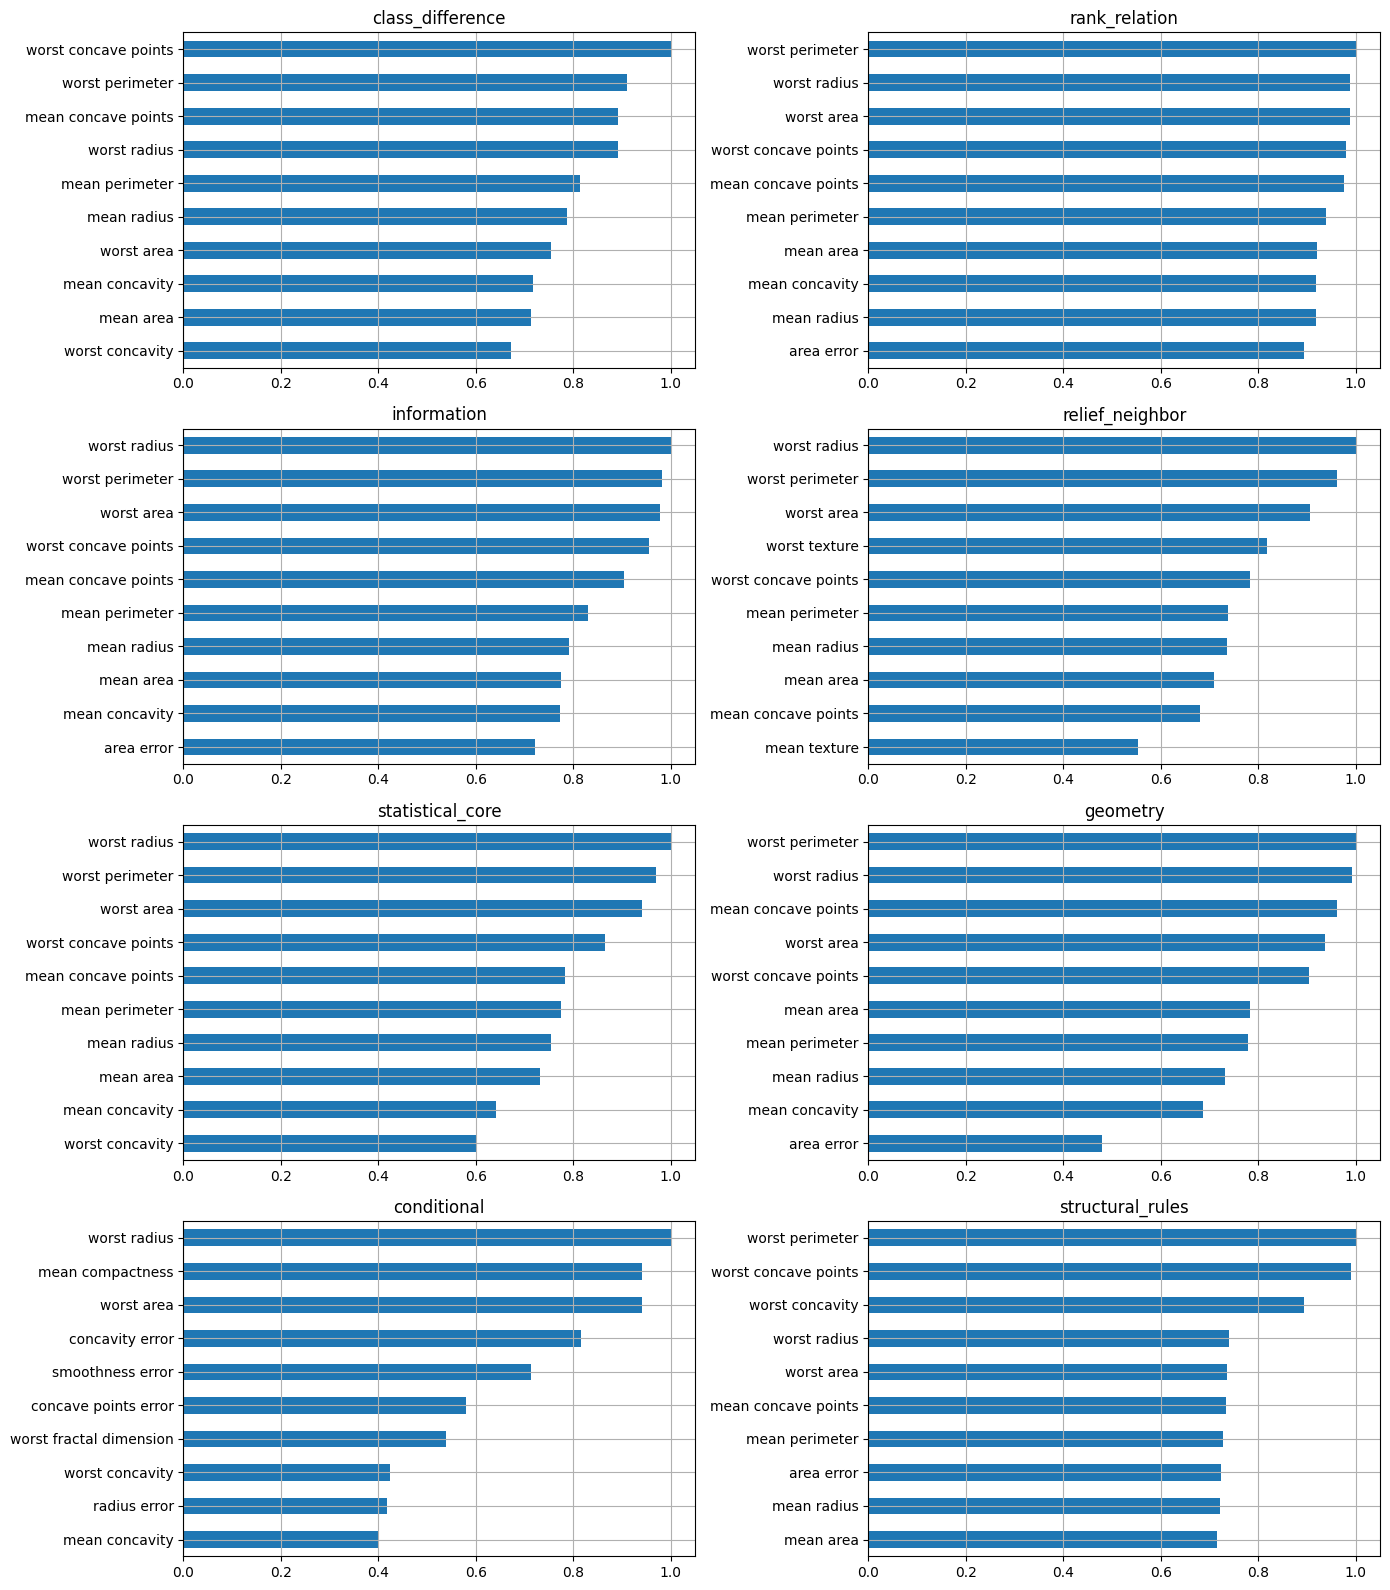

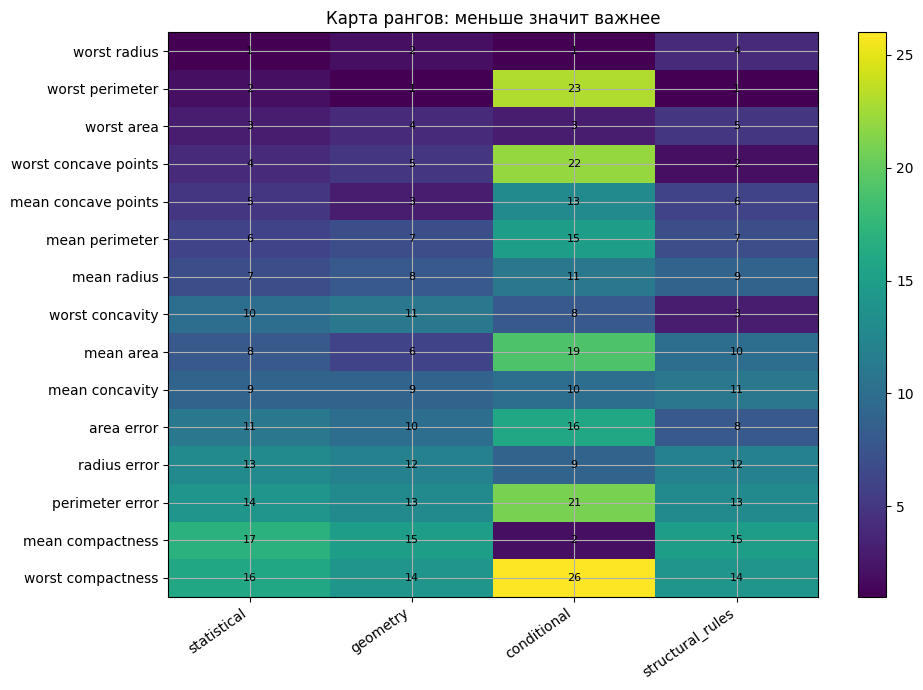

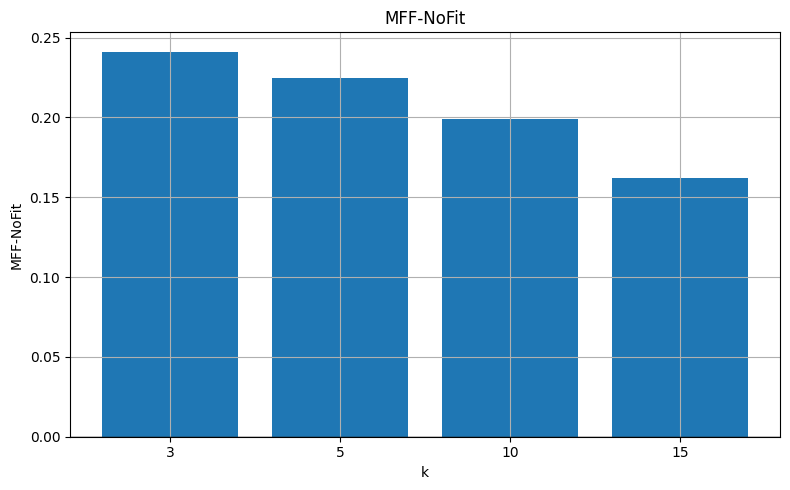

In [2]:
# Визуализация первых признаков по методам
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel()
for ax, col in zip(axes, scores.columns):
    scores[col].sort_values(ascending=True).tail(10).plot(kind='barh', ax=ax)
    ax.set_title(col)
for ax in axes[len(scores.columns):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Карта рангов
core_cols = ['statistical','geometry','conditional','structural_rules']
heat = ranks.head(15)[core_cols]
fig, ax = plt.subplots(figsize=(10,7))
im = ax.imshow(heat.values, aspect='auto')
ax.set_xticks(range(len(core_cols)))
ax.set_xticklabels(core_cols, rotation=35, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, str(int(heat.values[i,j])), ha='center', va='center', fontsize=8)
ax.set_title('Карта рангов: меньше значит важнее')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# MFF-NoFit
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(mff['k'].astype(str), mff['MFF_NoFit'])
ax.axhline(0, color='black', lw=1)
ax.set_title('MFF-NoFit')
ax.set_xlabel('k')
ax.set_ylabel('MFF-NoFit')
plt.tight_layout()
plt.show()